In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:
%run projeto_06.py

--- RESULTADOS DAS PREDIÇÕES: PROJETO 6 ---
Target Estudado: 'falha_maquina' (0: Normal, 1: Falha)

Máquina 1: {'temperatura_motor': 82.1, 'vibracao': 4.8, 'tipo_combustivel': 'Eletrico', 'revisao_em_dia': 'Sim'}
   - Predição de falha_maquina: 1
   - Probabilidade Negativa (0): 49.61%
   - Probabilidade Positiva (1): 50.39%

Máquina 2: {'temperatura_motor': 105.0, 'vibracao': 12.0, 'tipo_combustivel': 'Diesel', 'revisao_em_dia': 'Não'}
   - Predição de falha_maquina: 1
   - Probabilidade Negativa (0): 46.06%
   - Probabilidade Positiva (1): 53.94%



In [82]:
df_treino, novos = gerar_dados()
print("Tamanho do dataframe principal", df_treino.shape)
print("Tamanho dos dados novos:", novos.shape)
df_treino.head()

Tamanho do dataframe principal (1000, 5)
Tamanho dos dados novos: (2, 4)


,temperatura_motor,vibracao,tipo_combustivel,revisao_em_dia,falha_maquina
0,84.967142,7.099033,Eletrico,Não,0
1,78.617357,6.386951,Hibrido,Não,0
2,86.476885,5.089446,Hibrido,Não,0
3,95.230299,4.029595,Hibrido,Sim,1
4,77.658466,6.047335,Eletrico,Não,0


In [83]:
df_treino.dtypes

temperatura_motor    float64
vibracao             float64
tipo_combustivel      object
revisao_em_dia        object
falha_maquina          int64
dtype: object

In [84]:
df_treino.describe()
# Com isso é possível reparar que temos valores faltantes na vibração, 
# E ainda é possível notar, que essa coluna possui valores outliers 
# Também vale a pena observar o valor máximo da temperatura que está em 118.52


,temperatura_motor,vibracao,falha_maquina
count,1000.000000,976.000000,1000.000000
mean,80.193321,5.918946,0.498000
std,9.792159,8.185069,0.500246
min,47.587327,0.589417,0.000000
25%,73.524097,4.090637,0.000000
50%,80.253006,5.109114,0.000000
75%,86.479439,6.115360,1.000000
max,118.527315,85.000000,1.000000


In [85]:
df_treino["vibracao"].isna().sum()
# Temos 24 dados nulos de vibração, como são pouco podemos tomar a inciativa: 
# preencher esses dados nulos com a média

np.int64(24)

In [86]:
df_col_num = df_treino.dtypes[df_treino.dtypes != "object"].index
df_col_num

Index(['temperatura_motor', 'vibracao', 'falha_maquina'], dtype='object')

In [87]:
df_col_name = df_treino.dtypes[df_treino.dtypes == "object"].index
df_col_name

Index(['tipo_combustivel', 'revisao_em_dia'], dtype='object')

In [88]:
df_treino[df_col_name].describe()

,tipo_combustivel,revisao_em_dia
count,1000,1000
unique,3,2
top,Diesel,Não
freq,356,506


In [89]:
# index_temp = df_treino[df_treino["temperatura_motor"] == df_treino["temperatura_motor"].max()]
# print(index_temp)
index_vib = df_treino[df_treino["vibracao"] == df_treino["vibracao"].max()]
print(index_vib)

     temperatura_motor  vibracao tipo_combustivel revisao_em_dia  \
74           53.802549      85.0           Diesel            Sim   
354          79.809838      85.0           Diesel            Sim   
413          92.776768      85.0         Eletrico            Sim   
583         102.706929      85.0          Hibrido            Não   
684          67.778722      85.0          Hibrido            Não   
770          87.077519      85.0          Hibrido            Sim   
909         101.632547      85.0         Eletrico            Sim   
972          88.406435      85.0         Eletrico            Sim   
990          82.083828      85.0         Eletrico            Não   
991          59.582651      85.0         Eletrico            Sim   

     falha_maquina  
74               0  
354              1  
413              1  
583              1  
684              0  
770              0  
909              1  
972              0  
990              1  
991              1  


array([[<Axes: title={'center': 'vibracao'}>]], dtype=object)

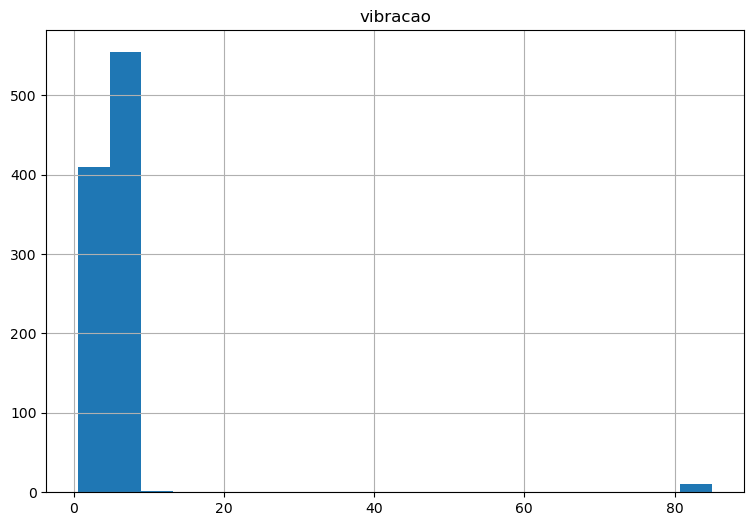

In [90]:
df_treino.hist(column = 'vibracao', figsize=(9, 6), bins=20)
# Repare que os dados se concentram num valor de vibração de até por volta de 10 
# e temos uma pequena exceção de dados que chegou a 80

In [91]:
# Substituíndo os dados outliers de vibração por nan
novos_dados_vibracao = np.where(df_treino["vibracao"] == df_treino["vibracao"].max(), np.nan, df_treino["vibracao"])
print(novos_dados_vibracao)
df_treino["vibracao"] = novos_dados_vibracao

[7.09903315 6.38695052 5.08944555 4.02959483 6.04733497 5.59022808
 6.34278983 5.9527577  6.57432907 4.19714718 6.9760911  5.29639941
        nan 3.96621827 7.6039457  5.29686618 4.02287299 4.27417125
 4.51947904 5.63624892 5.78425323 4.13944999 4.96346811 8.21340554
 7.59131476 5.6544855  5.05700522 5.18004699 5.92027696 3.46581115
 4.61393519 2.49712389 5.59883468 5.97079391 4.27522031 7.36098014
 3.16135151 2.80343768 5.33667773 6.57064745 7.52589154 4.31167361
 6.61802125 4.9422373         nan 6.32548991 5.97848432 2.63541176
 7.21481052 7.07013703 4.06165595 5.5937053  5.74104528 5.39101065
 4.17454227 3.99256495 4.96166889 6.75909353 5.81540023 4.4440785
 6.15754807 0.72718607 6.72314855 2.39042933 4.45633859        nan
 3.05797779 6.74124018 4.2984482  5.51975582 4.92961913 5.71556124
 5.11523284 3.07551166        nan 4.25936513 2.66512715 4.35782726
 7.25113969 6.27533261 4.4770218  4.47611344        nan 8.11512198
 5.57290318 5.64506247 6.54542518 5.35818374 4.61143678 4.70547

In [92]:
# Repare que agora temos 10 valores nulos a mais, que justamente dos outliers que trocamos por nan
print(df_treino["vibracao"].isna().sum())
# Trocando os valores nan pela média
novos_dados = np.where(df_treino["vibracao"].isna(), df_treino["vibracao"].mean(), df_treino["vibracao"])
print(novos_dados)
df_treino["vibracao"] = novos_dados

34
[7.09903315 6.38695052 5.08944555 4.02959483 6.04733497 5.59022808
 6.34278983 5.9527577  6.57432907 4.19714718 6.9760911  5.29639941
 5.10030199 3.96621827 7.6039457  5.29686618 4.02287299 4.27417125
 4.51947904 5.63624892 5.78425323 4.13944999 4.96346811 8.21340554
 7.59131476 5.6544855  5.05700522 5.18004699 5.92027696 3.46581115
 4.61393519 2.49712389 5.59883468 5.97079391 4.27522031 7.36098014
 3.16135151 2.80343768 5.33667773 6.57064745 7.52589154 4.31167361
 6.61802125 4.9422373  5.10030199 6.32548991 5.97848432 2.63541176
 7.21481052 7.07013703 4.06165595 5.5937053  5.74104528 5.39101065
 4.17454227 3.99256495 4.96166889 6.75909353 5.81540023 4.4440785
 6.15754807 0.72718607 6.72314855 2.39042933 4.45633859 5.10030199
 3.05797779 6.74124018 4.2984482  5.51975582 4.92961913 5.71556124
 5.11523284 3.07551166 5.10030199 4.25936513 2.66512715 4.35782726
 7.25113969 6.27533261 4.4770218  4.47611344 5.10030199 8.11512198
 5.57290318 5.64506247 6.54542518 5.35818374 4.61143678 4.70

In [93]:
df_treino[df_col_name].describe()

,tipo_combustivel,revisao_em_dia
count,1000,1000
unique,3,2
top,Diesel,Não
freq,356,506


array([[<Axes: title={'center': 'vibracao'}>]], dtype=object)

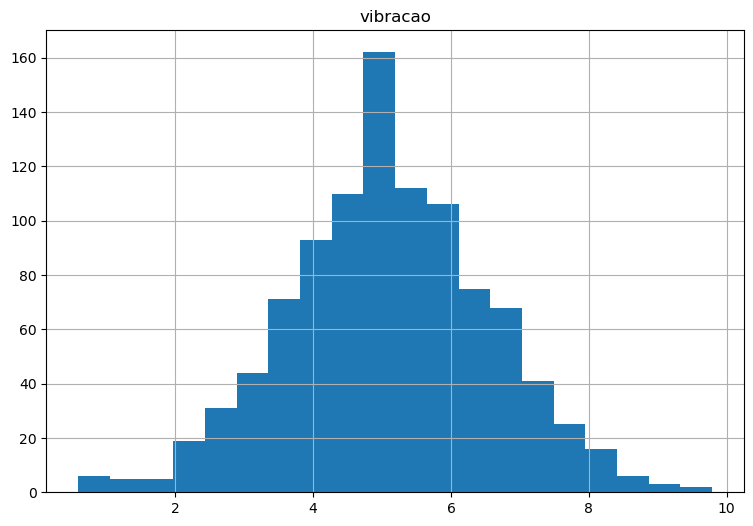

In [94]:
df_treino.hist(column = 'vibracao', figsize=(9, 6), bins=20)

<Axes: >

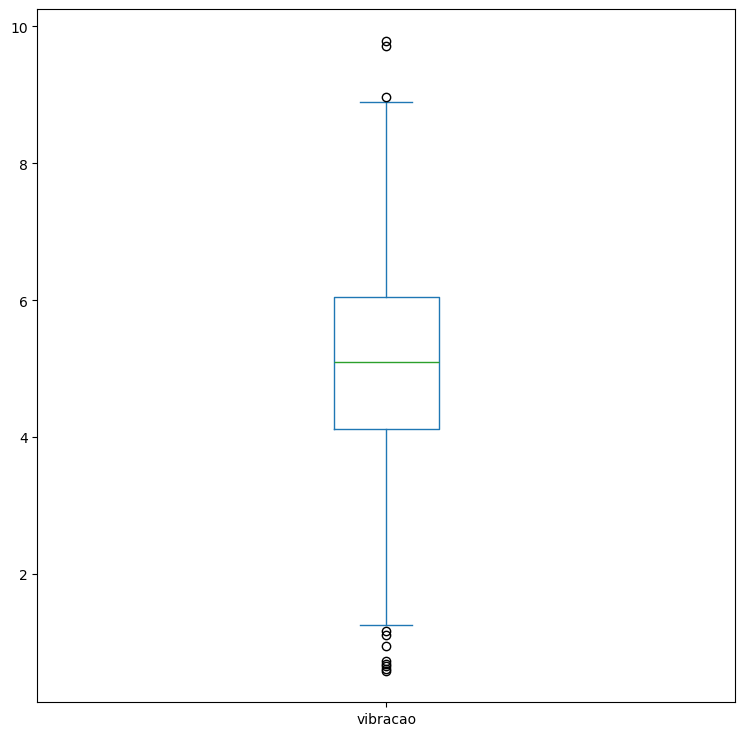

In [95]:
df_treino[df_col_num[1]].plot(kind="box", figsize=(9,9 ))

In [96]:
# Agora vamos começar a transformar os valores das colunas tipo combustível 
# e revisão em dia em formato categórico e realizar com conversão com técnicas
# de one hot enconding
df_treino[df_col_name[0]].unique()

array(['Eletrico', 'Hibrido', 'Diesel'], dtype=object)

In [97]:
df_treino[df_col_name[1]].unique()

array(['Não', 'Sim'], dtype=object)

In [98]:
# Convertendo os dados da coluna tipo combustível de objeto para categoria
# Transformando os valores em números
df_treino["tipo_combustivel"] = df_treino[df_col_name[0]].astype("category")
df_treino["tipo_combustivel"] = df_treino["tipo_combustivel"].cat.codes


In [99]:
df_treino["revisao_em_dia"] = df_treino["revisao_em_dia"].astype("category")
df_treino["revisao_em_dia"] = df_treino["revisao_em_dia"].cat.codes

In [100]:
df_treino.head()

,temperatura_motor,vibracao,tipo_combustivel,revisao_em_dia,falha_maquina
0,84.967142,7.099033,1,0,0
1,78.617357,6.386951,2,0,0
2,86.476885,5.089446,2,0,0
3,95.230299,4.029595,2,1,1
4,77.658466,6.047335,1,0,0


In [101]:
df_treino[df_col_name]

,tipo_combustivel,revisao_em_dia
0,1,0
1,2,0
2,2,0
3,2,1
4,1,0
...,...,...
995,0,0
996,1,0
997,2,0
998,1,0


In [102]:
# Salva o arquivo csv para evitar problemas, mas não é necessário 
df_treino.to_csv("dataset_projeto06_tratado.csv", index=False)
print("Arquivo CSV salvo com sucesso!")

Arquivo CSV salvo com sucesso!


In [103]:
# Tirando os dados de falha da máquina para realizar a divisão de treino e teste
y = df_treino["falha_maquina"]
x = df_treino.drop(columns="falha_maquina")

In [104]:
from sklearn.model_selection import train_test_split

seed = 42
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=seed, stratify=y)


In [105]:
df_col_num = df_col_num.drop("falha_maquina")

In [106]:
# Normalizando os dados de entrada de treino 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train[df_col_num] = scaler.fit_transform(x_train[df_col_num])
x_train.describe()

,temperatura_motor,vibracao,tipo_combustivel,revisao_em_dia
count,800.000000,800.000000,800.00000,800.000000
mean,0.458924,0.487834,0.97000,0.496250
std,0.136066,0.159947,0.83064,0.500299
min,0.000000,0.000000,0.00000,0.000000
25%,0.366730,0.380557,0.00000,0.000000
50%,0.457633,0.490301,1.00000,0.000000
75%,0.550505,0.589272,2.00000,1.000000
max,1.000000,1.000000,2.00000,1.000000


In [107]:
x_test[df_col_num] = scaler.transform(x_test[df_col_num])
x_test.describe()   

,temperatura_motor,vibracao,tipo_combustivel,revisao_em_dia
count,200.000000,200.000000,200.000000,200.000000
mean,0.462445,0.500166,0.955000,0.485000
std,0.145963,0.154615,0.797594,0.501029
min,0.083211,0.007195,0.000000,0.000000
25%,0.364150,0.400405,0.000000,0.000000
50%,0.471614,0.490311,1.000000,0.000000
75%,0.537756,0.606011,2.000000,1.000000
max,0.840349,0.899992,2.000000,1.000000


In [108]:
from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression(random_state=seed)
modelo.fit(x_train, y_train)
print("modelo treinado")

modelo treinado


In [109]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = modelo.predict(x_test)
acuracia = accuracy_score(y_test, y_pred)
print("Acurácia do modelo em medir falhas em motores: ", acuracia*100)

Acurácia do modelo em medir falhas em motores:  50.5
